# Accumulation time by bleaching rate

In [1]:
import os
import sys

path = os.path.abspath("")
splitted = path.split(os.sep)
user_independent = os.path.join(
    splitted[0] + os.sep, splitted[1], splitted[2], splitted[3]
)
src_path = os.path.join(user_independent, "GitHub", "Photoswitching")
sys.path.append(src_path)

import src.blinking as bl
import src.distributions as dist
import src.emissions as em
import src.fcs as fcs_p
import src.figure as fi
import src.fluorophores as fl
import src.formulas as fo
import src.miscellaneous as mi
import src.network as net
import src.simulation as si
import src.prediction as pr
import src.analysis as an
import src.transitions as tr

import numpy as np
import pandas as pd

%load_ext autoreload
%autoreload 2

import warnings


def custom_warning_format(msg, category, filename, lineno, line=None):
    if line is None:
        import linecache

        line = linecache.getline(filename, lineno)
    return f"WARNING for line: {line} {msg} \n"


warnings.formatwarning = custom_warning_format

c:\Users\vie43sq\Miniconda3\envs\MarkovModels\lib\site-packages\pycorrelate\pycorrelate.py:118: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  def ucorrelate(t, u, maxlag=None):


In [2]:
number_fluorophores = 1
distance = None
energy_transfers = False

irradiance = 2.5
wavelength = 640

photon_collection_rate = 0.01
emccd_gain = 100
bandpass_range = [600, 800]
frame_integration_time = '1ms'
quantum_eff_detec = 0.9

fluorophores = fl.construct_fluorophores('cy5', 1, number_fluorophores, 'square')
fluorophore_system = fl.FluorophoreSystem(fluorophores=fluorophores)
transitions = fluorophore_system.load_transitions(
    irradiance=irradiance, 
    wavelength=wavelength,
    bleaching=True,
    energy_transfer=False,
    dstorm=True,
    reducing_agent='mea',
    concentration=140,
    ph=8,
)
transition_set = tr.TransitionSet(transitions=transitions, fluorophore_system=fluorophore_system)

In [12]:
transition_set_1_f_bl_high = transition_set.adjust_rates({12:1e4})
transition_set_1_f_bl_high.finalize()

simulation_1_f_bl_high = si.Simulation(transition_set_1_f_bl_high)
bleaching_transitions = transition_set_1_f_bl_high.combined_state_transitions_df[transition_set_1_f_bl_high.combined_state_transitions_df['abbreviation'] == 'BLE1']
series_1_f_bl_high = pd.Series(np.zeros(300001), np.linspace(0, 300, 300001))
time_collection_1_f_bl_high = []
rng = np.random.default_rng(1)
times_80_percent_1f_bl_high = []
clustersizes_1f_bl_high = []
for _ in range(100):
    simulation_1_f_bl_high.run(start_at=None, size=1e6, end_time=300, seed=rng, use_memmap=None)
    times = simulation_1_f_bl_high.time_series[1:-1][np.in1d(simulation_1_f_bl_high.transition_series, bleaching_transitions.index)]
    time_collection_1_f_bl_high.append(times)
    emissions = em.Emissions(frame_time=frame_integration_time, seed=1, bandpass=bandpass_range)
    emissions.extract(simulation=simulation_1_f_bl_high)
    cum_sum = emissions.event_time_series.cumsum()
    rel_cum_sum = cum_sum / cum_sum.max()
    index = rel_cum_sum.index[rel_cum_sum > 0.8][0]
    size = emissions.event_time_series[emissions.event_time_series > 0].size
    times_80_percent_1f_bl_high.append(index)
    clustersizes_1f_bl_high.append(size)
    series_1_f_bl_high = series_1_f_bl_high + emissions.event_time_series.values

rel_emission_1_f_bl_high = series_1_f_bl_high.cumsum() / series_1_f_bl_high.sum()

In [14]:
transition_set_1_f_bl_mid = transition_set.adjust_rates({12:1e3})
transition_set_1_f_bl_mid.finalize()

simulation_1_f_bl_mid = si.Simulation(transition_set_1_f_bl_mid)
bleaching_transitions = transition_set_1_f_bl_mid.combined_state_transitions_df[transition_set_1_f_bl_mid.combined_state_transitions_df['abbreviation'] == 'BLE1']
series_1_f_bl_mid = pd.Series(np.zeros(300001), np.linspace(0, 300, 300001))
time_collection_1_f_bl_mid = []
rng = np.random.default_rng(1)
times_80_percent_1f_bl_mid = []
clustersizes_1f_bl_mid = []
for _ in range(100):
    simulation_1_f_bl_mid.run(start_at=None, size=1e6, end_time=300, seed=rng, use_memmap=None)
    times = simulation_1_f_bl_mid.time_series[1:-1][np.in1d(simulation_1_f_bl_mid.transition_series, bleaching_transitions.index)]
    time_collection_1_f_bl_mid.append(times)
    emissions = em.Emissions(frame_time=frame_integration_time, seed=1, bandpass=bandpass_range)
    emissions.extract(simulation=simulation_1_f_bl_mid)
    cum_sum = emissions.event_time_series.cumsum()
    rel_cum_sum = cum_sum / cum_sum.max()
    index = rel_cum_sum.index[rel_cum_sum > 0.8][0]
    size = emissions.event_time_series[emissions.event_time_series > 0].size
    times_80_percent_1f_bl_mid.append(index)
    clustersizes_1f_bl_mid.append(size)
    series_1_f_bl_mid = series_1_f_bl_mid + emissions.event_time_series.values

rel_emission_1_f_bl_mid = series_1_f_bl_mid.cumsum() / series_1_f_bl_mid.sum()

In [15]:
transition_set_1_f_bl_low = transition_set.adjust_rates({12:1e2})
transition_set_1_f_bl_low.finalize()

simulation_1_f_bl_low = si.Simulation(transition_set_1_f_bl_low)
bleaching_transitions = transition_set_1_f_bl_low.combined_state_transitions_df[transition_set_1_f_bl_low.combined_state_transitions_df['abbreviation'] == 'BLE1']
series_1_f_bl_low = pd.Series(np.zeros(300001), np.linspace(0, 300, 300001))
time_collection_1_f_bl_low = []
rng = np.random.default_rng(1)
times_80_percent_1f_bl_low = []
clustersizes_1f_bl_low = []
for _ in range(100):
    simulation_1_f_bl_low.run(start_at=None, size=1e6, end_time=300, seed=rng, use_memmap=None)
    times = simulation_1_f_bl_low.time_series[1:-1][np.in1d(simulation_1_f_bl_low.transition_series, bleaching_transitions.index)]
    time_collection_1_f_bl_low.append(times)
    emissions = em.Emissions(frame_time=frame_integration_time, seed=1, bandpass=bandpass_range)
    emissions.extract(simulation=simulation_1_f_bl_low)
    cum_sum = emissions.event_time_series.cumsum()
    rel_cum_sum = cum_sum / cum_sum.max()
    index = rel_cum_sum.index[rel_cum_sum > 0.8][0]
    size = emissions.event_time_series[emissions.event_time_series > 0].size
    times_80_percent_1f_bl_low.append(index)
    clustersizes_1f_bl_low.append(size)
    series_1_f_bl_low = series_1_f_bl_low + emissions.event_time_series.values

rel_emission_1_f_bl_low = series_1_f_bl_low.cumsum() / series_1_f_bl_low.sum()

In [16]:
transition_set_1_f_no_bl = transition_set.adjust_rates({12:0})
transition_set_1_f_no_bl.finalize()

simulation_1_f_no_bl = si.Simulation(transition_set_1_f_no_bl)
bleaching_transitions = transition_set_1_f_no_bl.combined_state_transitions_df[transition_set_1_f_no_bl.combined_state_transitions_df['abbreviation'] == 'BLE1']
series_1_f_no_bl = pd.Series(np.zeros(300001), np.linspace(0, 300, 300001))
time_collection_1_f_no_bl = []
rng = np.random.default_rng(1)
times_80_percent_1f_no_bl = []
clustersizes_1f_no_bl = []
for _ in range(100):
    simulation_1_f_no_bl.run(start_at=None, size=1e6, end_time=300, seed=rng, use_memmap=None)
    times = simulation_1_f_no_bl.time_series[1:-1][np.in1d(simulation_1_f_no_bl.transition_series, bleaching_transitions.index)]
    time_collection_1_f_no_bl.append(times)
    emissions = em.Emissions(frame_time=frame_integration_time, seed=1, bandpass=bandpass_range)
    emissions.extract(simulation=simulation_1_f_no_bl)
    cum_sum = emissions.event_time_series.cumsum()
    rel_cum_sum = cum_sum / cum_sum.max()
    index = rel_cum_sum.index[rel_cum_sum > 0.8][0]
    size = emissions.event_time_series[emissions.event_time_series >0].size
    times_80_percent_1f_no_bl.append(index)
    clustersizes_1f_no_bl.append(size)
    series_1_f_no_bl = series_1_f_no_bl + emissions.event_time_series.values

rel_emission_1_f_no_bl = series_1_f_no_bl.cumsum() / series_1_f_no_bl.sum()

array([[<AxesSubplot:title={'center':'1f bl high'}, xlabel='localizations', ylabel='80% time [s]'>]],
      dtype=object)

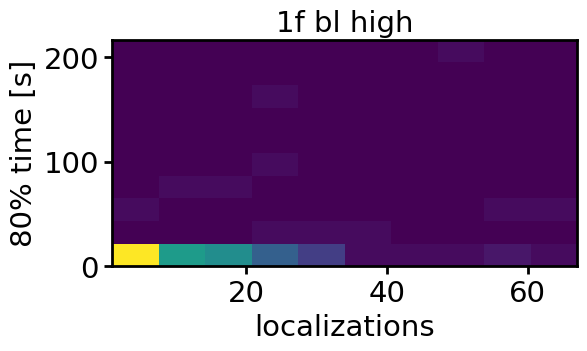

In [17]:
fi.universal_figure(type_='2d_hist', data=[clustersizes_1f_bl_high, times_80_percent_1f_bl_high], 
                    ylabel='80% time [s]', xlabel='localizations', title='1f bl high')

array([[<AxesSubplot:title={'center':'1f bl mid'}, xlabel='localizations', ylabel='80% time [s]'>]],
      dtype=object)

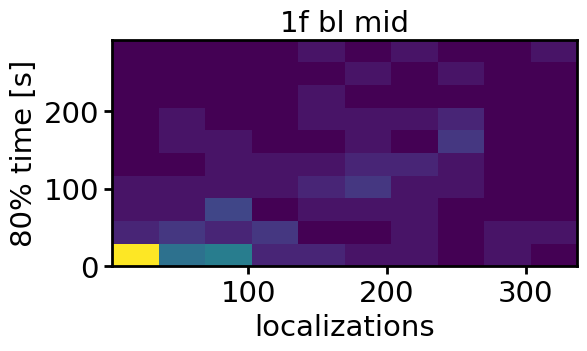

In [18]:
fi.universal_figure(type_='2d_hist', data=[clustersizes_1f_bl_mid, times_80_percent_1f_bl_mid], 
                    ylabel='80% time [s]', xlabel='localizations', title='1f bl mid')

array([[<AxesSubplot:title={'center':'1f bl low'}, xlabel='localizations', ylabel='80% time [s]'>]],
      dtype=object)

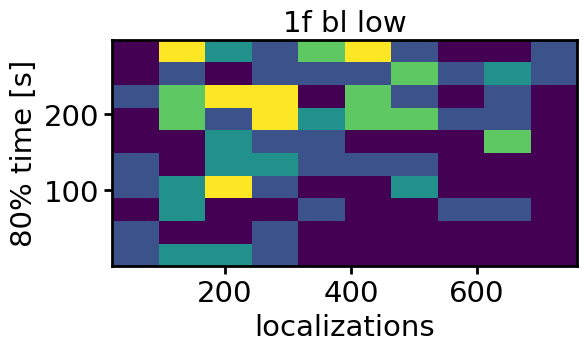

In [19]:
fi.universal_figure(type_='2d_hist', data=[clustersizes_1f_bl_low, times_80_percent_1f_bl_low], 
                    ylabel='80% time [s]', xlabel='localizations', title='1f bl low')

array([[<AxesSubplot:title={'center':'1f no bl'}, xlabel='localizations', ylabel='80% time [s]'>]],
      dtype=object)

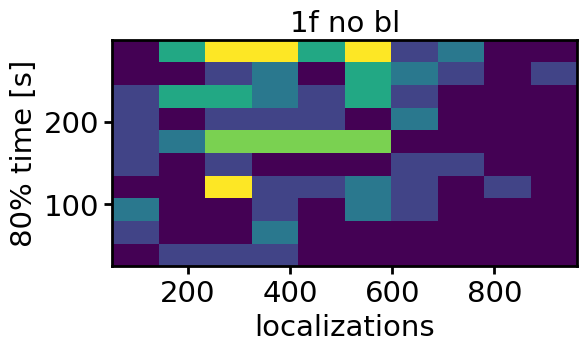

In [20]:
fi.universal_figure(type_='2d_hist', data=[clustersizes_1f_no_bl, times_80_percent_1f_no_bl], 
                    ylabel='80% time [s]', xlabel='localizations', title='1f no bl')

array([[<Axes: xlabel='time [s]', ylabel='% emission'>]], dtype=object)

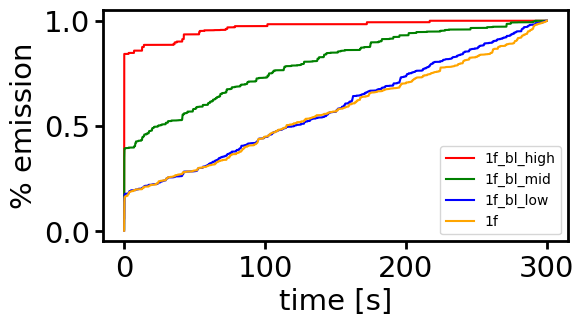

In [15]:
ax = fi.universal_figure(data=[series_1_f_bl_high.index, rel_emission_1_f_bl_high], label='1f_bl_high', color='red')
fi.universal_figure(data=[series_1_f_bl_mid.index, rel_emission_1_f_bl_mid], label='1f_bl_mid', axes=ax, color='green')
fi.universal_figure(data=[series_1_f_bl_low.index, rel_emission_1_f_bl_low], label='1f_bl_low', axes=ax, color='blue')
fi.universal_figure(data=[series_1_f_no_bl.index, rel_emission_1_f_no_bl], label='1f', axes=ax, color='orange', legend=True, xlabel='time [s]', ylabel='% emission')